# Feature Engineering - IEEE-CIS Fraud Detection

Runs the full pipeline from `src/features/build_features.py` and validates:
1. Pipeline execution and output shapes
2. Leakage check: temporal features use only past data
3. Feature distribution sanity checks
4. Engineered feature correlation with isFraud

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Add project root to path so we can import src/
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.features.build_features import (
    load_raw, drop_high_missing, add_has_identity,
    engineer_temporal_features, chronological_split,
    encode_categoricals, fill_missing, run_pipeline,
)

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"

print("Imports OK. ROOT:", ROOT)

Imports OK. ROOT: /Users/egedenizpekel/ForkDefault/portfolio-projects/transaction-anomaly-explainer


## 1. Run the Full Pipeline

In [2]:
run_pipeline(DATA_RAW, DATA_PROCESSED)

2026-03-05 05:30:28,327 INFO Loading train_transaction.csv ...


2026-03-05 05:30:33,110 INFO Loading train_identity.csv ...


2026-03-05 05:30:33,282 INFO Transactions: 590,540 rows x 394 cols


2026-03-05 05:30:33,282 INFO Identity    : 144,233 rows x 41 cols


2026-03-05 05:30:33,640 INFO After join  : 590,540 rows x 434 cols


...

2026-03-05 05:30:39,693 INFO Saving parquet files ...


2026-03-05 05:30:41,089 INFO Saved to /Users/egedenizpekel/ForkDefault/portfolio-projects/transaction-anomaly-explainer/data/processed


2026-03-05 05:30:41,090 INFO   features_train.parquet : 413,378 rows x 237 cols


2026-03-05 05:30:41,090 INFO   features_val.parquet   : 88,581 rows x 237 cols


2026-03-05 05:30:41,090 INFO   features_test.parquet  : 88,581 rows x 237 cols


## 2. Load Outputs and Check Shapes

In [3]:
train = pd.read_parquet(DATA_PROCESSED / "features_train.parquet")
val   = pd.read_parquet(DATA_PROCESSED / "features_val.parquet")
test  = pd.read_parquet(DATA_PROCESSED / "features_test.parquet")

for name, df in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:5s}: {df.shape[0]:>7,} rows x {df.shape[1]:>3} cols | "
          f"fraud rate: {df['isFraud'].mean()*100:.2f}% | "
          f"TransactionDT: {df['TransactionDT'].min():,} - {df['TransactionDT'].max():,}")

print(f"\nEngineered features present:")
engineered = ["hour_of_day", "day_of_week", "TransactionAmt_log", "TransactionAmt_zscore",
              "amt_to_mean_ratio", "time_since_last_txn", "txn_velocity_1h",
              "is_new_device", "has_identity", "card_amt_mean", "card_amt_std"]
for f in engineered:
    status = "OK" if f in train.columns else "MISSING"
    print(f"  {f:30s} {status}")

train: 413,378 rows x 237 cols | fraud rate: 3.52% | TransactionDT: 86,400 - 10,437,996
val  :  88,581 rows x 237 cols | fraud rate: 3.43% | TransactionDT: 10,438,003 - 13,151,840
test :  88,581 rows x 237 cols | fraud rate: 3.48% | TransactionDT: 13,151,880 - 15,811,131

Engineered features present:
  hour_of_day                    OK
  day_of_week                    OK
  TransactionAmt_log             OK
  TransactionAmt_zscore          OK
  amt_to_mean_ratio              OK
  time_since_last_txn            OK
  txn_velocity_1h                OK
  is_new_device                  OK
  has_identity                   OK
  card_amt_mean                  OK
  card_amt_std                   OK


## 3. Leakage Check

For 10 random val-set transactions, recompute `TransactionAmt_zscore` using only training rows
for that card and assert it matches the stored value.

In [4]:
rng = np.random.default_rng(42)

# Load raw to get original TransactionAmt (pre-encoding) and card1 values
raw_txn = pd.read_csv(DATA_RAW / "train_transaction.csv",
                      usecols=["TransactionID", "TransactionDT", "TransactionAmt", "card1", "isFraud"])
raw_txn = raw_txn.sort_values("TransactionDT").reset_index(drop=True)

# Get train boundary TransactionDT
train_max_dt = train["TransactionDT"].max()

# Sample 10 val transactions that have a card seen in training
val_sample_ids = val["TransactionID"].sample(50, random_state=42)
val_sample_raw = raw_txn[raw_txn["TransactionID"].isin(val_sample_ids)].copy()

# Filter to cards that exist in training data
train_cards = set(raw_txn[raw_txn["TransactionDT"] <= train_max_dt]["card1"].unique())
val_sample_raw = val_sample_raw[val_sample_raw["card1"].isin(train_cards)].head(10)

failures = 0
print(f"{'TxnID':>12} {'card1':>8} {'stored_zscore':>14} {'recomputed':>12} {'match':>6}")
print("-" * 60)

for _, row in val_sample_raw.iterrows():
    card = row["card1"]
    dt   = row["TransactionDT"]
    amt  = row["TransactionAmt"]
    txn_id = row["TransactionID"]

    # All training rows for this card strictly before this transaction
    card_history = raw_txn[
        (raw_txn["card1"] == card) & (raw_txn["TransactionDT"] < dt)
    ]["TransactionAmt"]

    if len(card_history) < 2:
        print(f"{txn_id:>12} {card:>8}  {'(insufficient history)':>26}")
        continue

    recomputed_mean = card_history.mean()
    recomputed_std  = card_history.std()
    recomputed_z    = (amt - recomputed_mean) / recomputed_std if recomputed_std > 0 else np.nan

    stored_z = val.loc[val["TransactionID"] == txn_id, "TransactionAmt_zscore"].values
    stored_z = stored_z[0] if len(stored_z) > 0 else np.nan

    match = np.isclose(recomputed_z, stored_z, atol=0.01, equal_nan=True)
    if not match:
        failures += 1
    print(f"{txn_id:>12} {card:>8} {stored_z:>14.4f} {recomputed_z:>12.4f} {'OK' if match else 'FAIL':>6}")

print(f"\nLeakage check: {failures} failures out of checked rows")
if failures == 0:
    print("PASSED - no temporal leakage detected")
else:
    print("FAILED - review feature engineering pipeline")

       TxnID    card1  stored_zscore   recomputed  match
------------------------------------------------------------
   3401090.0   7919.0        -0.4037      -0.4037     OK
   3407718.0   6530.0        -0.1332      -0.1332     OK
   3412127.0   6344.0        -0.2247      -0.2247     OK
   3413013.0  15372.0        -0.1976      -0.1976     OK
   3414188.0   8903.0        -1.5000      -1.5000     OK
   3415162.0  17480.0        -0.4778      -0.4778     OK
   3418910.0  15885.0         1.2455       1.2455     OK
   3424195.0   2779.0        -0.2399      -0.2399     OK
   3424414.0   7207.0        -0.5420      -0.5420     OK
   3424512.0  10112.0        -0.4215      -0.4215     OK

Leakage check: 0 failures out of checked rows
PASSED - no temporal leakage detected


## 4. Engineered Feature Distributions

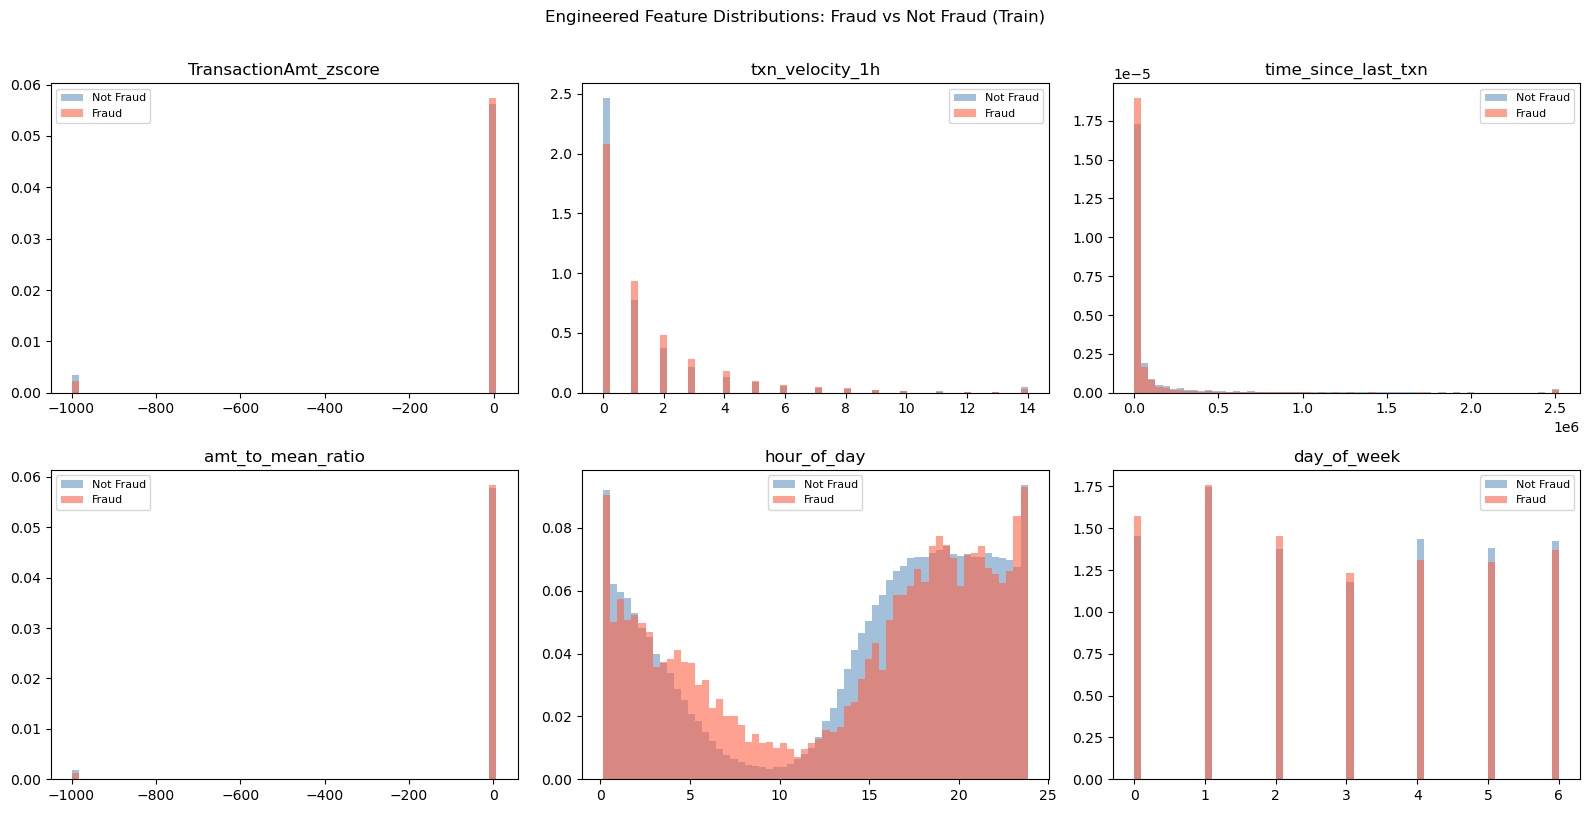

In [5]:
features_to_plot = [
    "TransactionAmt_zscore", "txn_velocity_1h",
    "time_since_last_txn", "amt_to_mean_ratio",
    "hour_of_day", "day_of_week",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, feat in zip(axes, features_to_plot):
    if feat not in train.columns:
        ax.set_visible(False)
        continue

    # Clip extreme values for readability
    p1, p99 = train[feat].quantile([0.01, 0.99])
    data = train[feat].clip(p1, p99)

    ax.hist(data[train["isFraud"] == 0], bins=60, alpha=0.5,
            color="steelblue", label="Not Fraud", density=True)
    ax.hist(data[train["isFraud"] == 1], bins=60, alpha=0.6,
            color="tomato", label="Fraud", density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle("Engineered Feature Distributions: Fraud vs Not Fraud (Train)", y=1.01)
plt.tight_layout()
plt.show()

## 5. Engineered Feature Correlations with isFraud

Engineered feature |correlation| with isFraud:
time_since_last_txn      0.016752
TransactionAmt_zscore    0.014538
hour_of_day              0.012217
amt_to_mean_ratio        0.011642
day_of_week              0.008383
txn_velocity_1h          0.003663
TransactionAmt_log       0.001583
is_new_device                 NaN
has_identity                  NaN


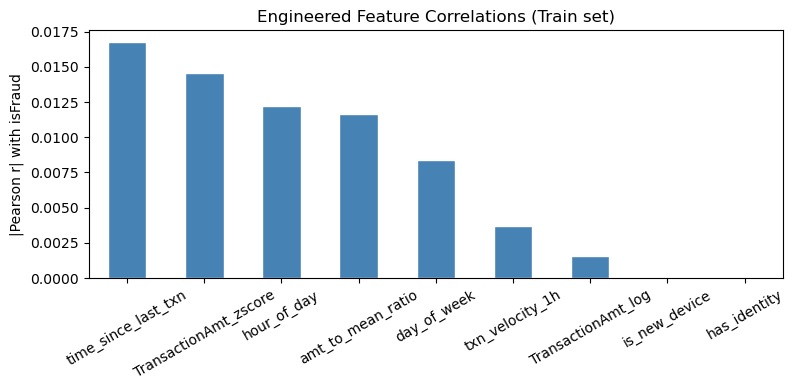

In [6]:
engineered_feats = [
    "hour_of_day", "day_of_week", "TransactionAmt_log", "TransactionAmt_zscore",
    "amt_to_mean_ratio", "time_since_last_txn", "txn_velocity_1h",
    "is_new_device", "has_identity",
]
available = [f for f in engineered_feats if f in train.columns]

corr = train[available + ["isFraud"]].corr()["isFraud"].drop("isFraud").abs().sort_values(ascending=False)

print("Engineered feature |correlation| with isFraud:")
print(corr.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
corr.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_ylabel("|Pearson r| with isFraud")
ax.set_title("Engineered Feature Correlations (Train set)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 6. Missing Value Check on Processed Data

In [7]:
remaining_nulls = train.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]

if len(remaining_nulls) == 0:
    print("No missing values in train set after pipeline. PASSED.")
else:
    print(f"WARNING: {len(remaining_nulls)} columns still have nulls:")
    print(remaining_nulls.sort_values(ascending=False).head(20))

# Confirm -999 sentinel is present for expected numerics
print(f"\nRows with TransactionAmt_zscore == -999: {(train['TransactionAmt_zscore'] == -999).sum():,}")
print(f"(Expected: cards with only 1 transaction have no std, so zscore = -999)")

No missing values in train set after pipeline. PASSED.

Rows with TransactionAmt_zscore == -999: 22,984
(Expected: cards with only 1 transaction have no std, so zscore = -999)
